In [34]:
# Prepare dataset for environment
%pip install ucimlrepo
%pip install kneed

# Import packages to be used
from ucimlrepo import fetch_ucirepo 
import matplotlib.pyplot as plt
import pandas as pd
import numpy as np
# import plotly.graph_objects as go


Note: you may need to restart the kernel to use updated packages.


In [35]:
######## Power Consumption Dataset ##########
# Multivariate, Classification, Clustering

# Fetch the dataset 
diabetes_130_us_hospitals_for_years_1999_2008 = fetch_ucirepo(id=296) 
  
# data (as pandas dataframes) 
x = diabetes_130_us_hospitals_for_years_1999_2008.data.features 
y = diabetes_130_us_hospitals_for_years_1999_2008.data.targets

# metadata 
# print(diabetes_130_us_hospitals_for_years_1999_2008.metadata) 
  
# variable information 
# print(diabetes_130_us_hospitals_for_years_1999_2008.variables) 

# Set data as pandas dataframe 
df = x.join(y)
# print(df)

# Algorithms: k-means clustering, Principal component analysis
# Goal is to determine the early readmission of the patient within  30 days of discharge.

C:\Users\anher\AppData\Local\Temp/ipykernel_19316/954731602.py:5: DtypeWarning: Columns (10) have mixed types.Specify dtype option on import or set low_memory=False.
  diabetes_130_us_hospitals_for_years_1999_2008 = fetch_ucirepo(id=296)


In [36]:
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 101766 entries, 0 to 101765
Data columns (total 48 columns):
 #   Column                    Non-Null Count   Dtype 
---  ------                    --------------   ----- 
 0   race                      99493 non-null   object
 1   gender                    101766 non-null  object
 2   age                       101766 non-null  object
 3   weight                    3197 non-null    object
 4   admission_type_id         101766 non-null  int64 
 5   discharge_disposition_id  101766 non-null  int64 
 6   admission_source_id       101766 non-null  int64 
 7   time_in_hospital          101766 non-null  int64 
 8   payer_code                61510 non-null   object
 9   medical_specialty         51817 non-null   object
 10  num_lab_procedures        101766 non-null  int64 
 11  num_procedures            101766 non-null  int64 
 12  num_medications           101766 non-null  int64 
 13  number_outpatient         101766 non-null  int64 
 14  numb

In [37]:
print(df[df.isna().any(axis=1)])

                   race  gender      age weight  admission_type_id  \
0             Caucasian  Female   [0-10)    NaN                  6   
1             Caucasian  Female  [10-20)    NaN                  1   
2       AfricanAmerican  Female  [20-30)    NaN                  1   
3             Caucasian    Male  [30-40)    NaN                  1   
4             Caucasian    Male  [40-50)    NaN                  1   
...                 ...     ...      ...    ...                ...   
101761  AfricanAmerican    Male  [70-80)    NaN                  1   
101762  AfricanAmerican  Female  [80-90)    NaN                  1   
101763        Caucasian    Male  [70-80)    NaN                  1   
101764        Caucasian  Female  [80-90)    NaN                  2   
101765        Caucasian    Male  [70-80)    NaN                  1   

        discharge_disposition_id  admission_source_id  time_in_hospital  \
0                             25                    1                 1   
1        

In [38]:
##### Data Cleaning ###### 
# Check Data types
# df.info()

### Check for missing values ###
naCheck = df.isna().any().any()
print(naCheck)

# print("This is naCheck1")
# naCheck1 = df.isna().any()
# print(naCheck1)


# print("This is naCheck3")
# naCheck3 = df.isna().any(axis=None)
# print(naCheck3)

print("This gives the number of NA values for each column")
naCheck4 = df.isna().sum()
print(naCheck4)

# naCheck2 = np.any(np.isnan(df)) # This is an iterable that uses even the column headers.
# np.isinf(df).any().any()
# np.any(np.isnan(df))
# print(naCheck2)

# Found missing values
if naCheck == True:
    replacements = {'cola': 0, 'colb': 'Other'}
    dfChecked = df.fillna(replacements)
    print(dfChecked)

True
This gives the number of NA values for each column
race                         2273
gender                          0
age                             0
weight                      98569
admission_type_id               0
discharge_disposition_id        0
admission_source_id             0
time_in_hospital                0
payer_code                  40256
medical_specialty           49949
num_lab_procedures              0
num_procedures                  0
num_medications                 0
number_outpatient               0
number_emergency                0
number_inpatient                0
diag_1                         21
diag_2                        358
diag_3                       1423
number_diagnoses                0
max_glu_serum                   0
A1Cresult                       0
metformin                       0
repaglinide                     0
nateglinide                     0
chlorpropamide                  0
glimepiride                     0
acetohexamide             

In [ ]:
######## Missing Value Handling ########

datatypes = {'race': 'object', 'weight': 'object', 'payer_code': 'object', 'medical_specialty': 'object', 'diag_1': 'object', 'diag_2': 'object', 'diag_3': 'object'}
replaceType = {'object': 'Other', 'int64': 0 }
toReplace = {'race': 'Other', 'weight': 'Other', 'payer_code': 'Other', 'medical_specialty': 'Other', 'diag_1': 'Other', 'diag_2': 'Other', 'diag_3': 'Other'}

cols_with_missing = df.columns[df.isna().any()].tolist()
type(cols_with_missing[0])


dfChecked = dfChecked.fillna(toReplace)
# for i in cols_with_missing:
    # name = str(cols_with_missing[i])
    # df.loc[:,cols_with_missing[i]].fillna(replaceType.get(cols_with_missing[i]))
    #df.loc[:,cols_with_missing[i]].fillna(replaceType.get(datatypes.get(cols_with_missing[i])))
    #df.loc[:,cols_with_missing[i]].fillna(toReplace)
# print(cols_with_missing[0])
# df.loc[:,cols_with_missing[0]]
# print(replaceType.get(datatypes.get('race')))

    

In [76]:
# Recheck the data 
dfChecked.isna().sum()

race                        0
gender                      0
age                         0
weight                      0
admission_type_id           0
discharge_disposition_id    0
admission_source_id         0
time_in_hospital            0
payer_code                  0
medical_specialty           0
num_lab_procedures          0
num_procedures              0
num_medications             0
number_outpatient           0
number_emergency            0
number_inpatient            0
diag_1                      0
diag_2                      0
diag_3                      0
number_diagnoses            0
max_glu_serum               0
A1Cresult                   0
metformin                   0
repaglinide                 0
nateglinide                 0
chlorpropamide              0
glimepiride                 0
acetohexamide               0
glipizide                   0
glyburide                   0
tolbutamide                 0
pioglitazone                0
rosiglitazone               0
acarbose  

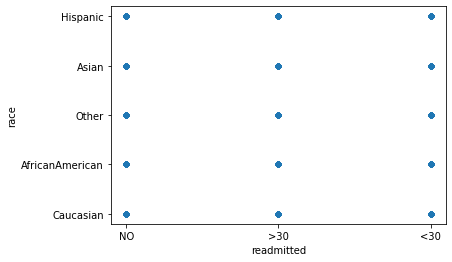

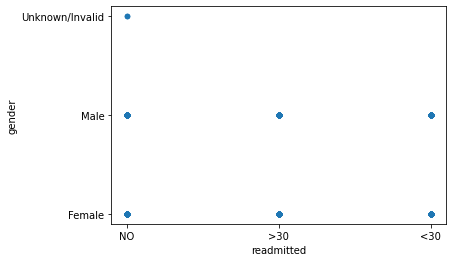

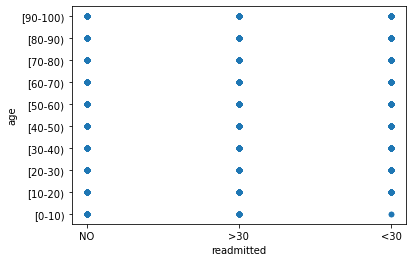

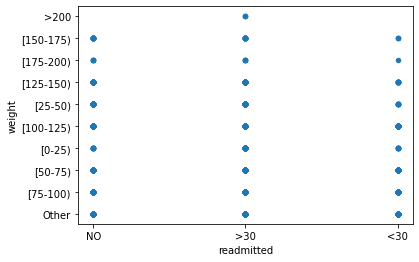

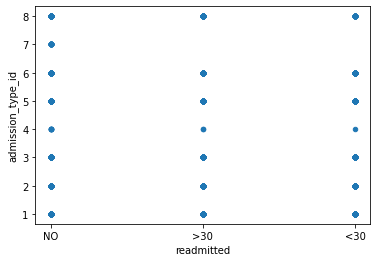

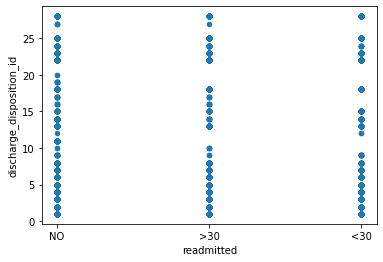

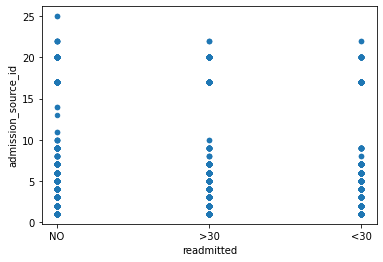

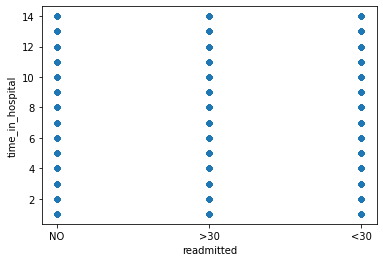

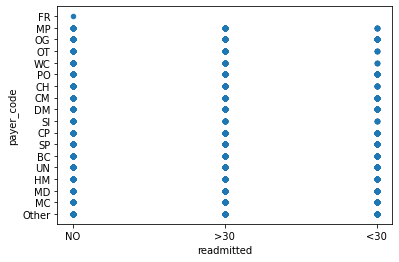

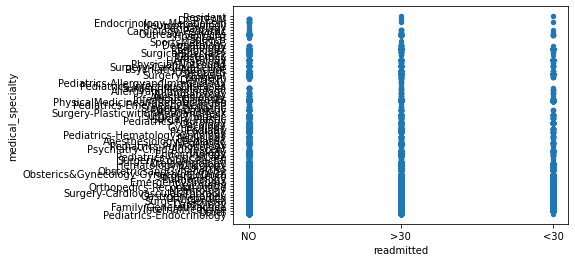

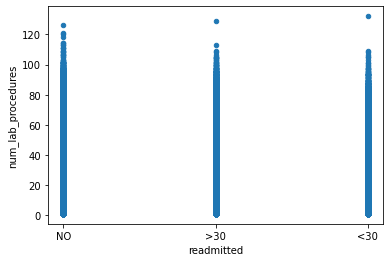

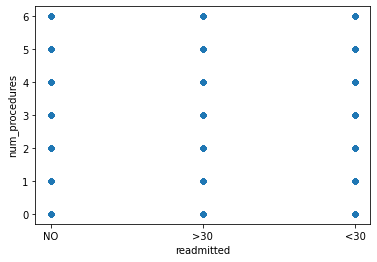

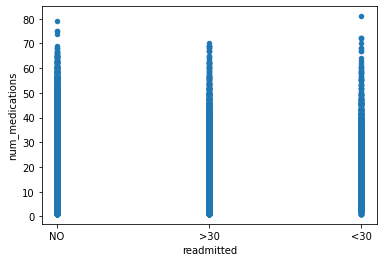

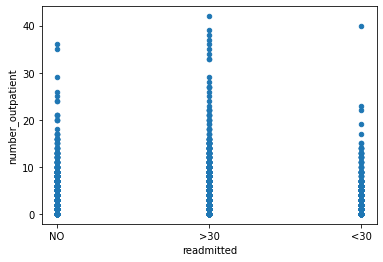

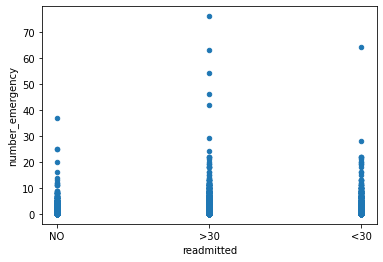

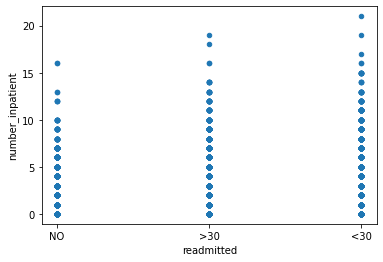

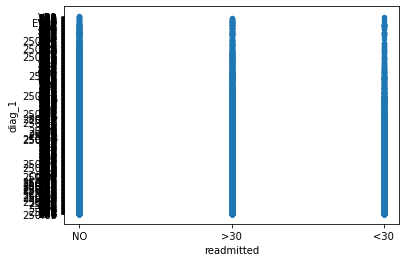

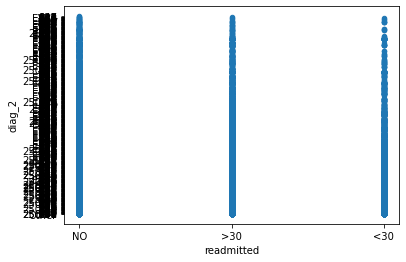

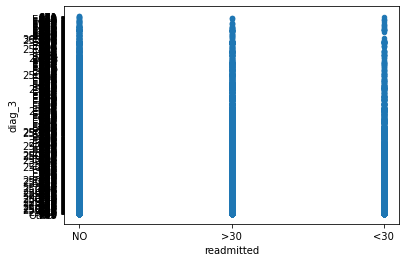

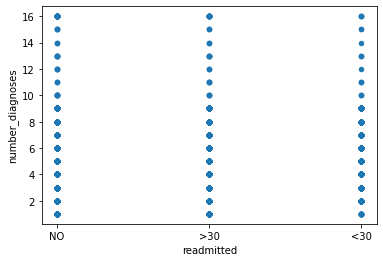

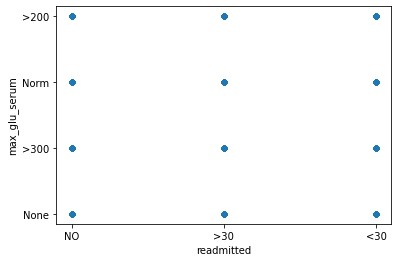

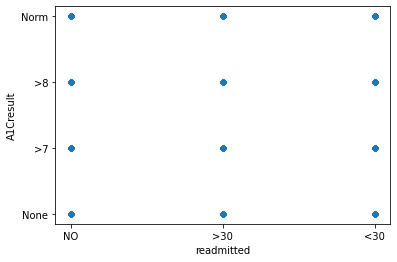

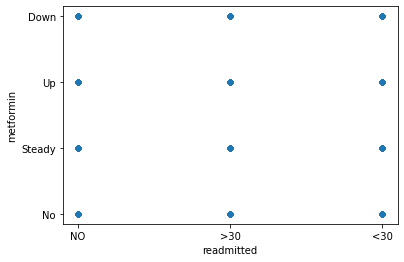

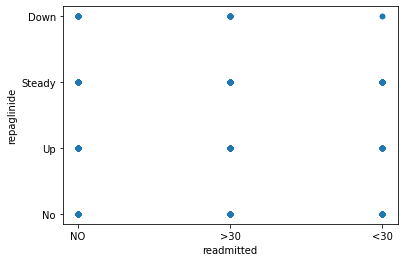

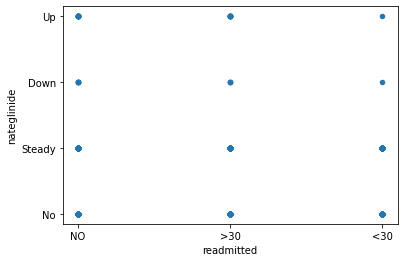

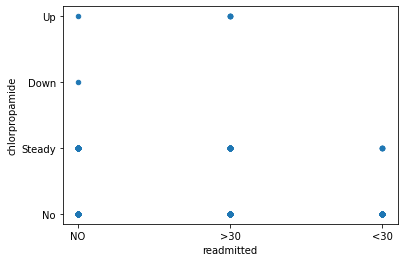

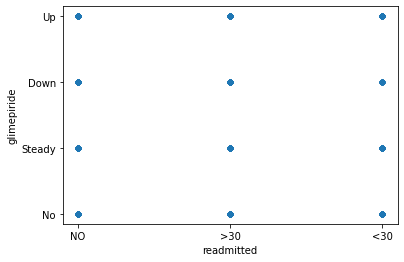

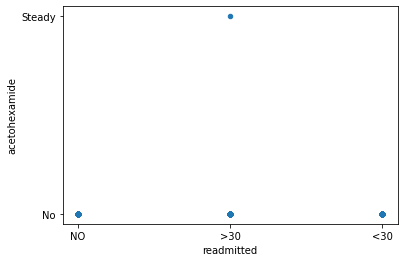

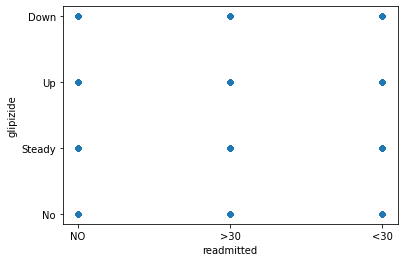

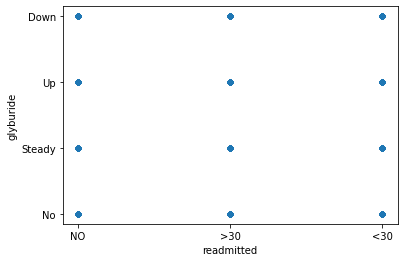

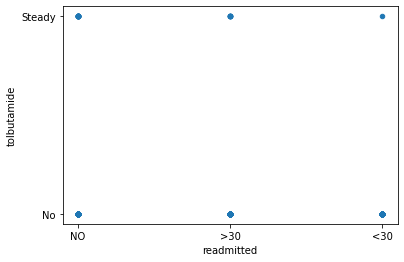

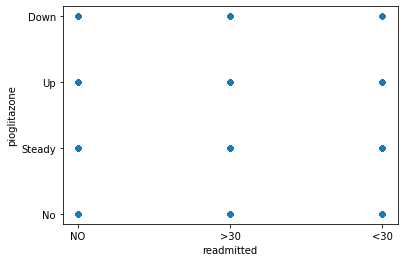

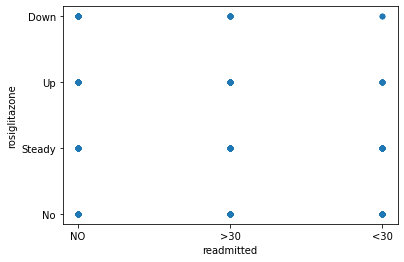

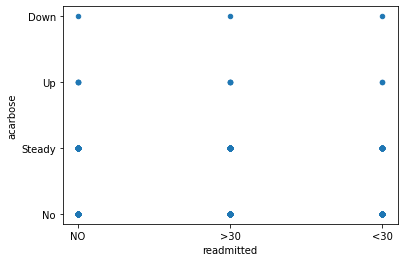

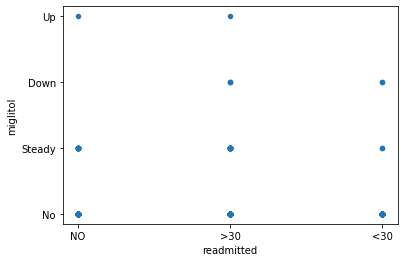

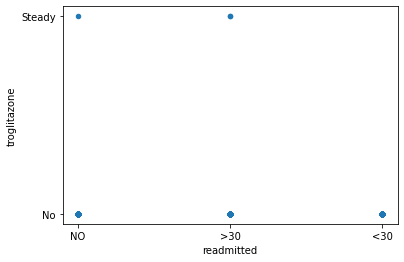

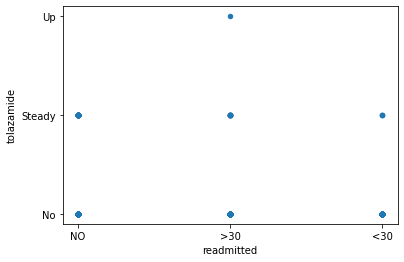

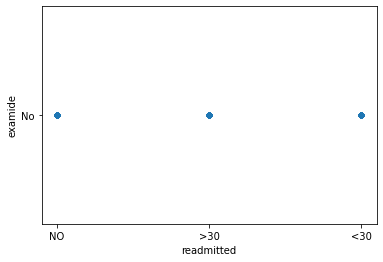

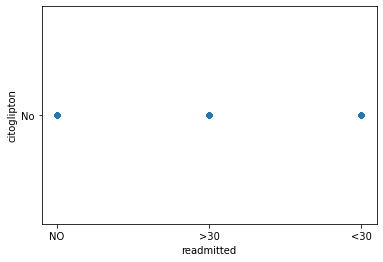

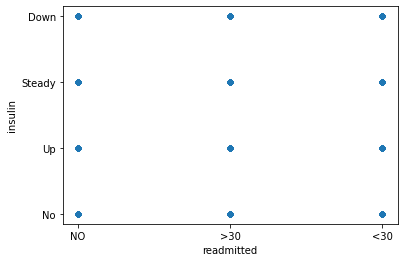

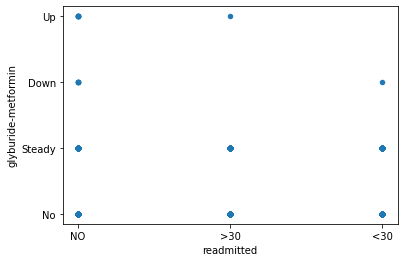

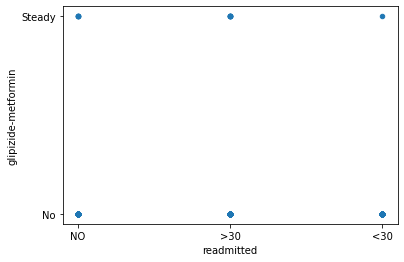

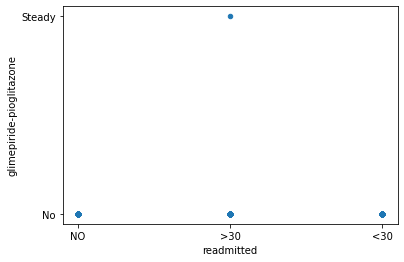

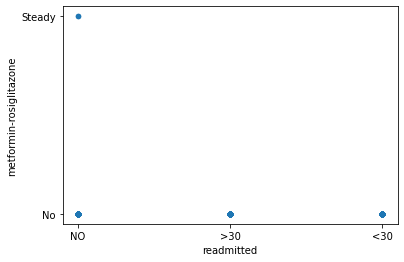

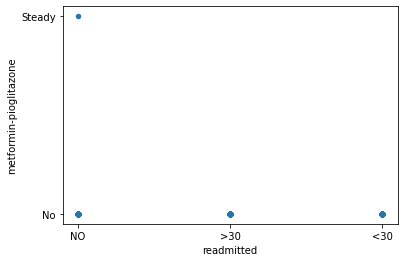

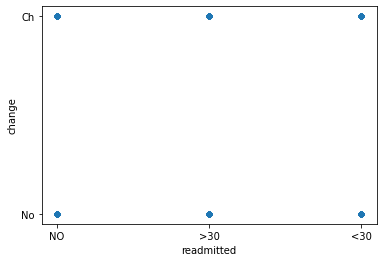

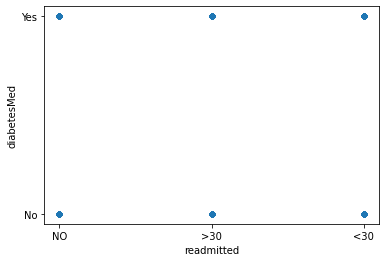

In [88]:
# How to graph the 47 columns in dfChecked against readmitted?
# Identify your target x-axis column
target_col = 'readmitted'

# Loop through all other columns
for col in dfChecked.columns:
    if col != target_col:
        dfChecked.plot(x=target_col, y=col, kind='scatter')
        plt.show()